In [ ]:
import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from particles.kalman import Kalman
import particles.state_space_models as ssms

from particles_cdssm.core import CDSSM_SMC, SMC
import particles_cdssm.plot as splt
import particles_cdssm.feynman_kac as sfk
from cdssm_lib import CDSSM_LIB 
from particles_cdssm.tools import build_cdssm
from particles_cdssm.continuous_discrete_ssms import NormalCDSSM, MvNormalCDSSM
import particles_cdssm.auxiliary_bridges as axb

# Filtering Test

We use this notebook to present the results of the filtering test:

Choose the cdssm that you would like to test below:

In [2]:
run_id = '50'
cdssm_str = 'ibm'

df_part_1 = pd.read_json(f'./results/filtering_test_run_{run_id}_{cdssm_str}_part_1.json')
df_part_2 = pd.read_json(f'./results/filtering_test_run_{run_id}_{cdssm_str}_part_2.json')
df_part_3 = pd.read_json(f'./results/filtering_test_run_{run_id}_{cdssm_str}_part_3.json')

with open(f'./results/filtering_test_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
    metadata = dill.load(f)

In [3]:
# Work with copies of the original dfs
df_1 = df_part_1.copy()
df_2 = df_part_2.copy() 
df_3 = df_part_3.copy()

# Extract the metadata
cdssm = metadata['cdssm']
lgssm = metadata['lgssm']
x = metadata['x']
y = metadata['y']
T = len(y)
N = metadata['N']
nruns_smc = metadata['nruns_smc']
nruns_cdssm_smc = metadata['nruns_cdssm_smc']

ext = '' if cdssm.islgssm else '_pf'
dimX = cdssm.dimX

print(f'Model: {cdssm_str}, T: {T}, N: {N}')
print(f'params: {cdssm.params}')

Model: ibm, T: 10, N: 100
params: {'m': array([[0.]]), 's': array([[1.]]), 'G': array([[1., 0.]]), 'covY': array([[0.0004]])}


# Plot of the CD-SSM

We plot below the simulation of the CD-SSM of interest. We choose a model such that ratio of observation noise/signal noise is high. The smoothing distribution changes materially as the total number of observations increases. 

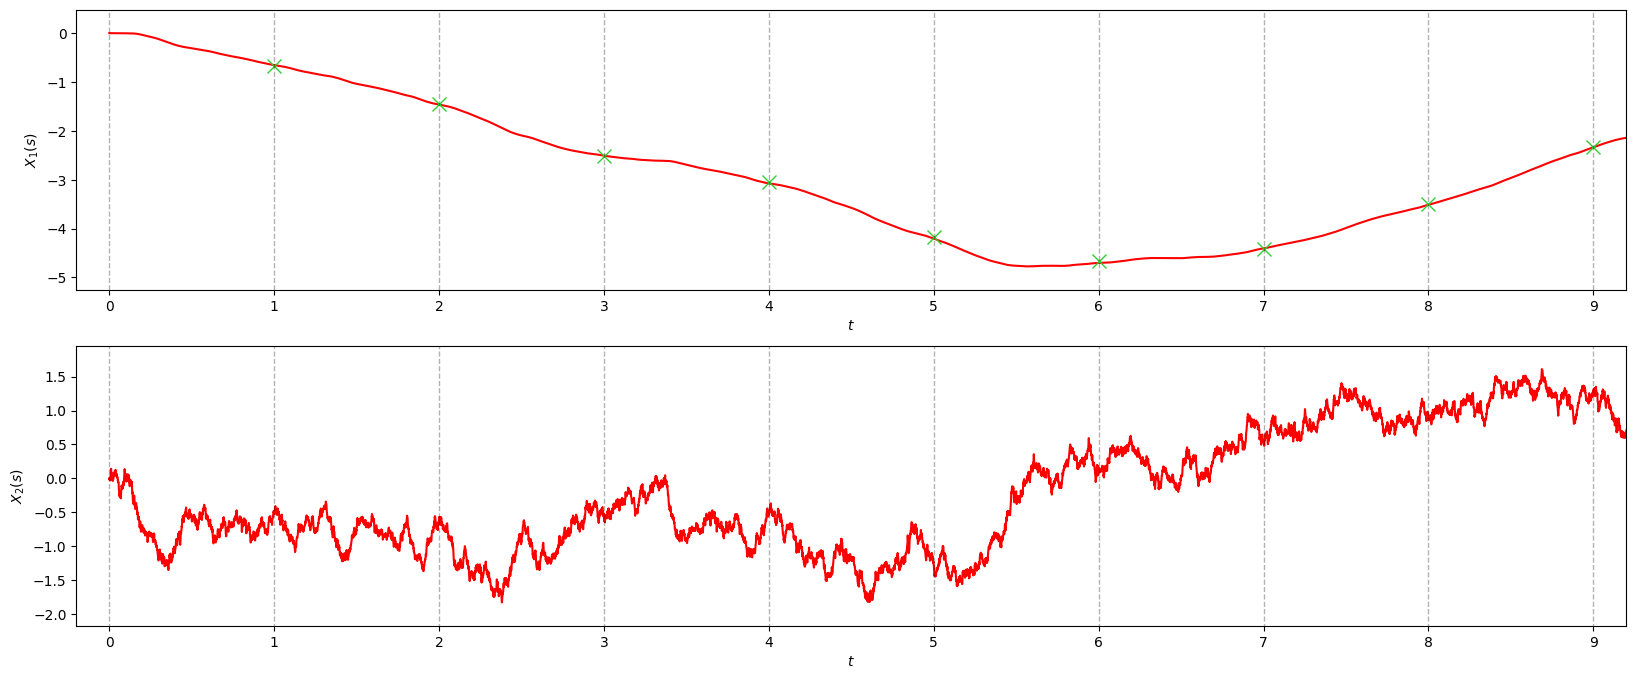

In [4]:
cdssm = build_cdssm('iou', smoothing=False)

x, y = cdssm.simulate(20)

plot_T = 9

x_plt = x[:plot_T + 2]
y_plt = y[:plot_T + 2]

#quantiles = metadata['quantiles']

if isinstance(cdssm, NormalCDSSM): 
    fig, axes = splt.cdssm_simulation_plot(cdssm, x_plt, y_plt)
elif isinstance(cdssm, MvNormalCDSSM):
    fig, axes = splt.mv_cdssm_simulation_plot(cdssm, x_plt, y_plt)
else:
    pass

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for ax in axes:
    ax.set_xlim((-0.2, plot_T + 0.2))
plt.show()

# Can add custom changes to the fig/axes below:

In [5]:
true_vals_df = df_1
results_df = pd.concat([df_2, df_3], axis=0)

In [6]:
colnames = ['logLt'] + [f'x_T_{d+1}' for d in range(dimX)] + [f'x_T_var_{d+1}' for d in range(dimX)] + [f'x_T_std_{d+1}' for d in range(dimX)]

for colname in colnames:
    results_df[colname + '_sq_err'] = np.square(results_df[colname + '_est'] - true_vals_df.loc[0, colname])
    results_df[colname + '_abs_err'] = np.abs(results_df[colname + '_est'] - true_vals_df.loc[0, colname])
    
abs_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'abs_err' in col]].copy()
sq_err_df = results_df[['fk'] + [col for col in results_df.columns.tolist() if 'sq_err' in col]].copy()
cpu_df = results_df[['fk'] + ['cpu']].copy()

mae_df = abs_err_df.groupby('fk').mean()
mse_df = sq_err_df.groupby('fk').mean()

mae_order = mae_df.sort_values(by='logLt_abs_err', ascending=False).index.tolist()

(0.0, 0.5)

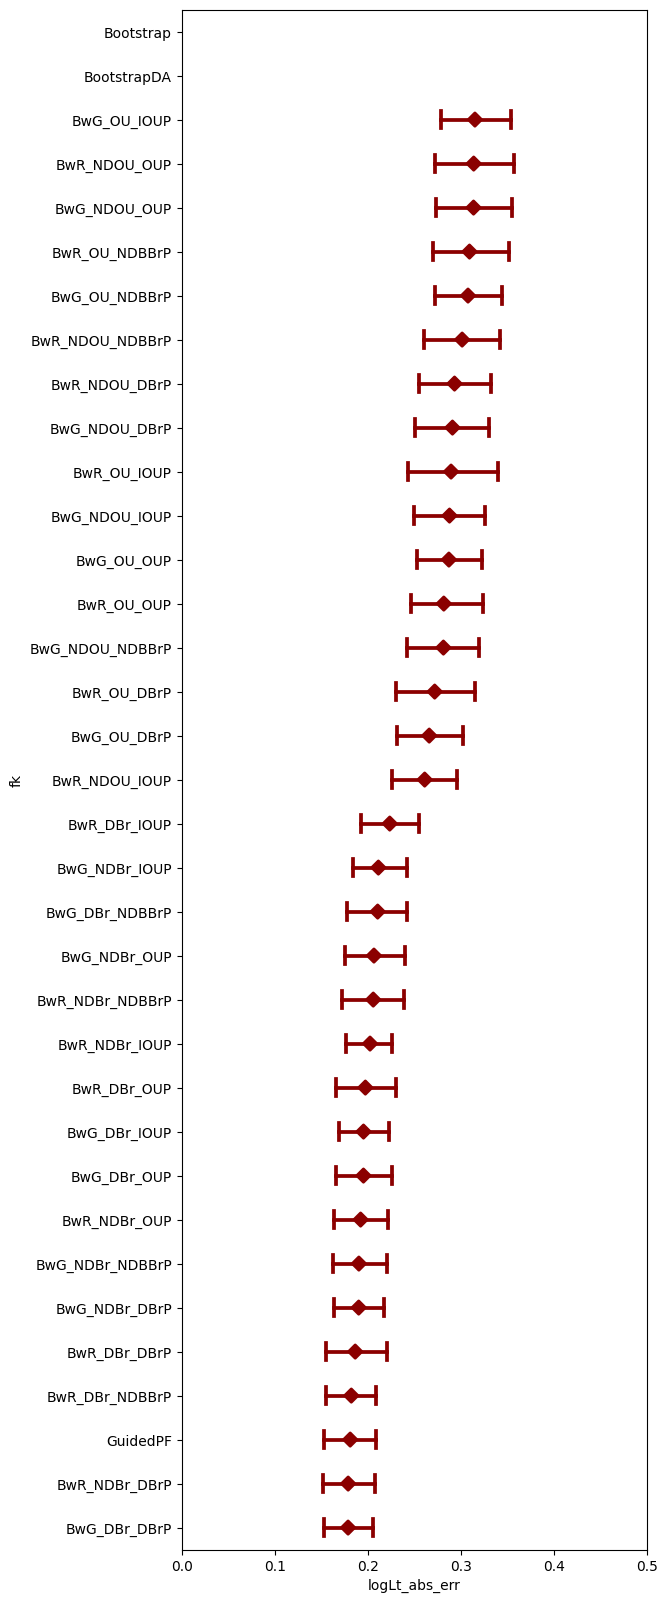

In [7]:
sns.pointplot(data=abs_err_df, y='fk', order = mae_order, linestyles="none", markers='D', color= 'darkred', capsize=0.4, x=f'logLt_abs_err')
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(6, 20)
ax.set_xlim((0, 0.5))

In [8]:
def test_mae_order(mae_order, cdssm_str):
    """
    Test whether performance of CDSSM_SMC estimators of log(p(y_{1:T}))
    are as expected.
    """
    cdssm_spec = CDSSM_LIB[cdssm_str]
    n_b = cdssm_spec['n_bottom_fks']; n_t = cdssm_spec['n_top_fks']
    # Check if the bottom n_b methods are all bootstrap methods
    print(f'Bottom {n_b} fk models:', mae_order[:n_b])
    cond = lambda x: x.startswith('BsR') or x.startswith('Bootstrap')
    assert np.all([cond(mae_str) for mae_str in mae_order[:n_b]]), f'Bottom {n_b} methods for cdssm {cdssm_str} are not all bootstrap methods.'

    # Check if the last n_t methods all use the true diffusion bridge
    print(f'Top {n_t} fk models:', mae_order[-n_t:])
    if cdssm_str.endswith('ou'):
        cond = lambda x: x.startswith('Guided') or x.split('_')[1].endswith('OU')
    else:
        cond = lambda x: x.startswith('Guided') or (not x.split('_')[1].endswith('OU'))
    assert np.all([cond(mae_str) for mae_str in mae_order[-n_t:]]), f'Top {n_t} methods for cdssm {cdssm_str} do not all use the true diffusion bridge.'

    # Check if the last 3 methods are all optimal guided methods ( ou only)
    if cdssm_str == 'ou':
        print('Top 3 fk models:', mae_order[-3:])
        cond = lambda x: x.startswith('Guided') or (x.split('_')[1] == 'OU' and x.split('_')[2] == 'OUP')
        assert np.all([cond(mae_str) for mae_str in mae_order[-3:]])
    print(f'All tests passed. MAE order is as expected for cdssm {cdssm_str}.')

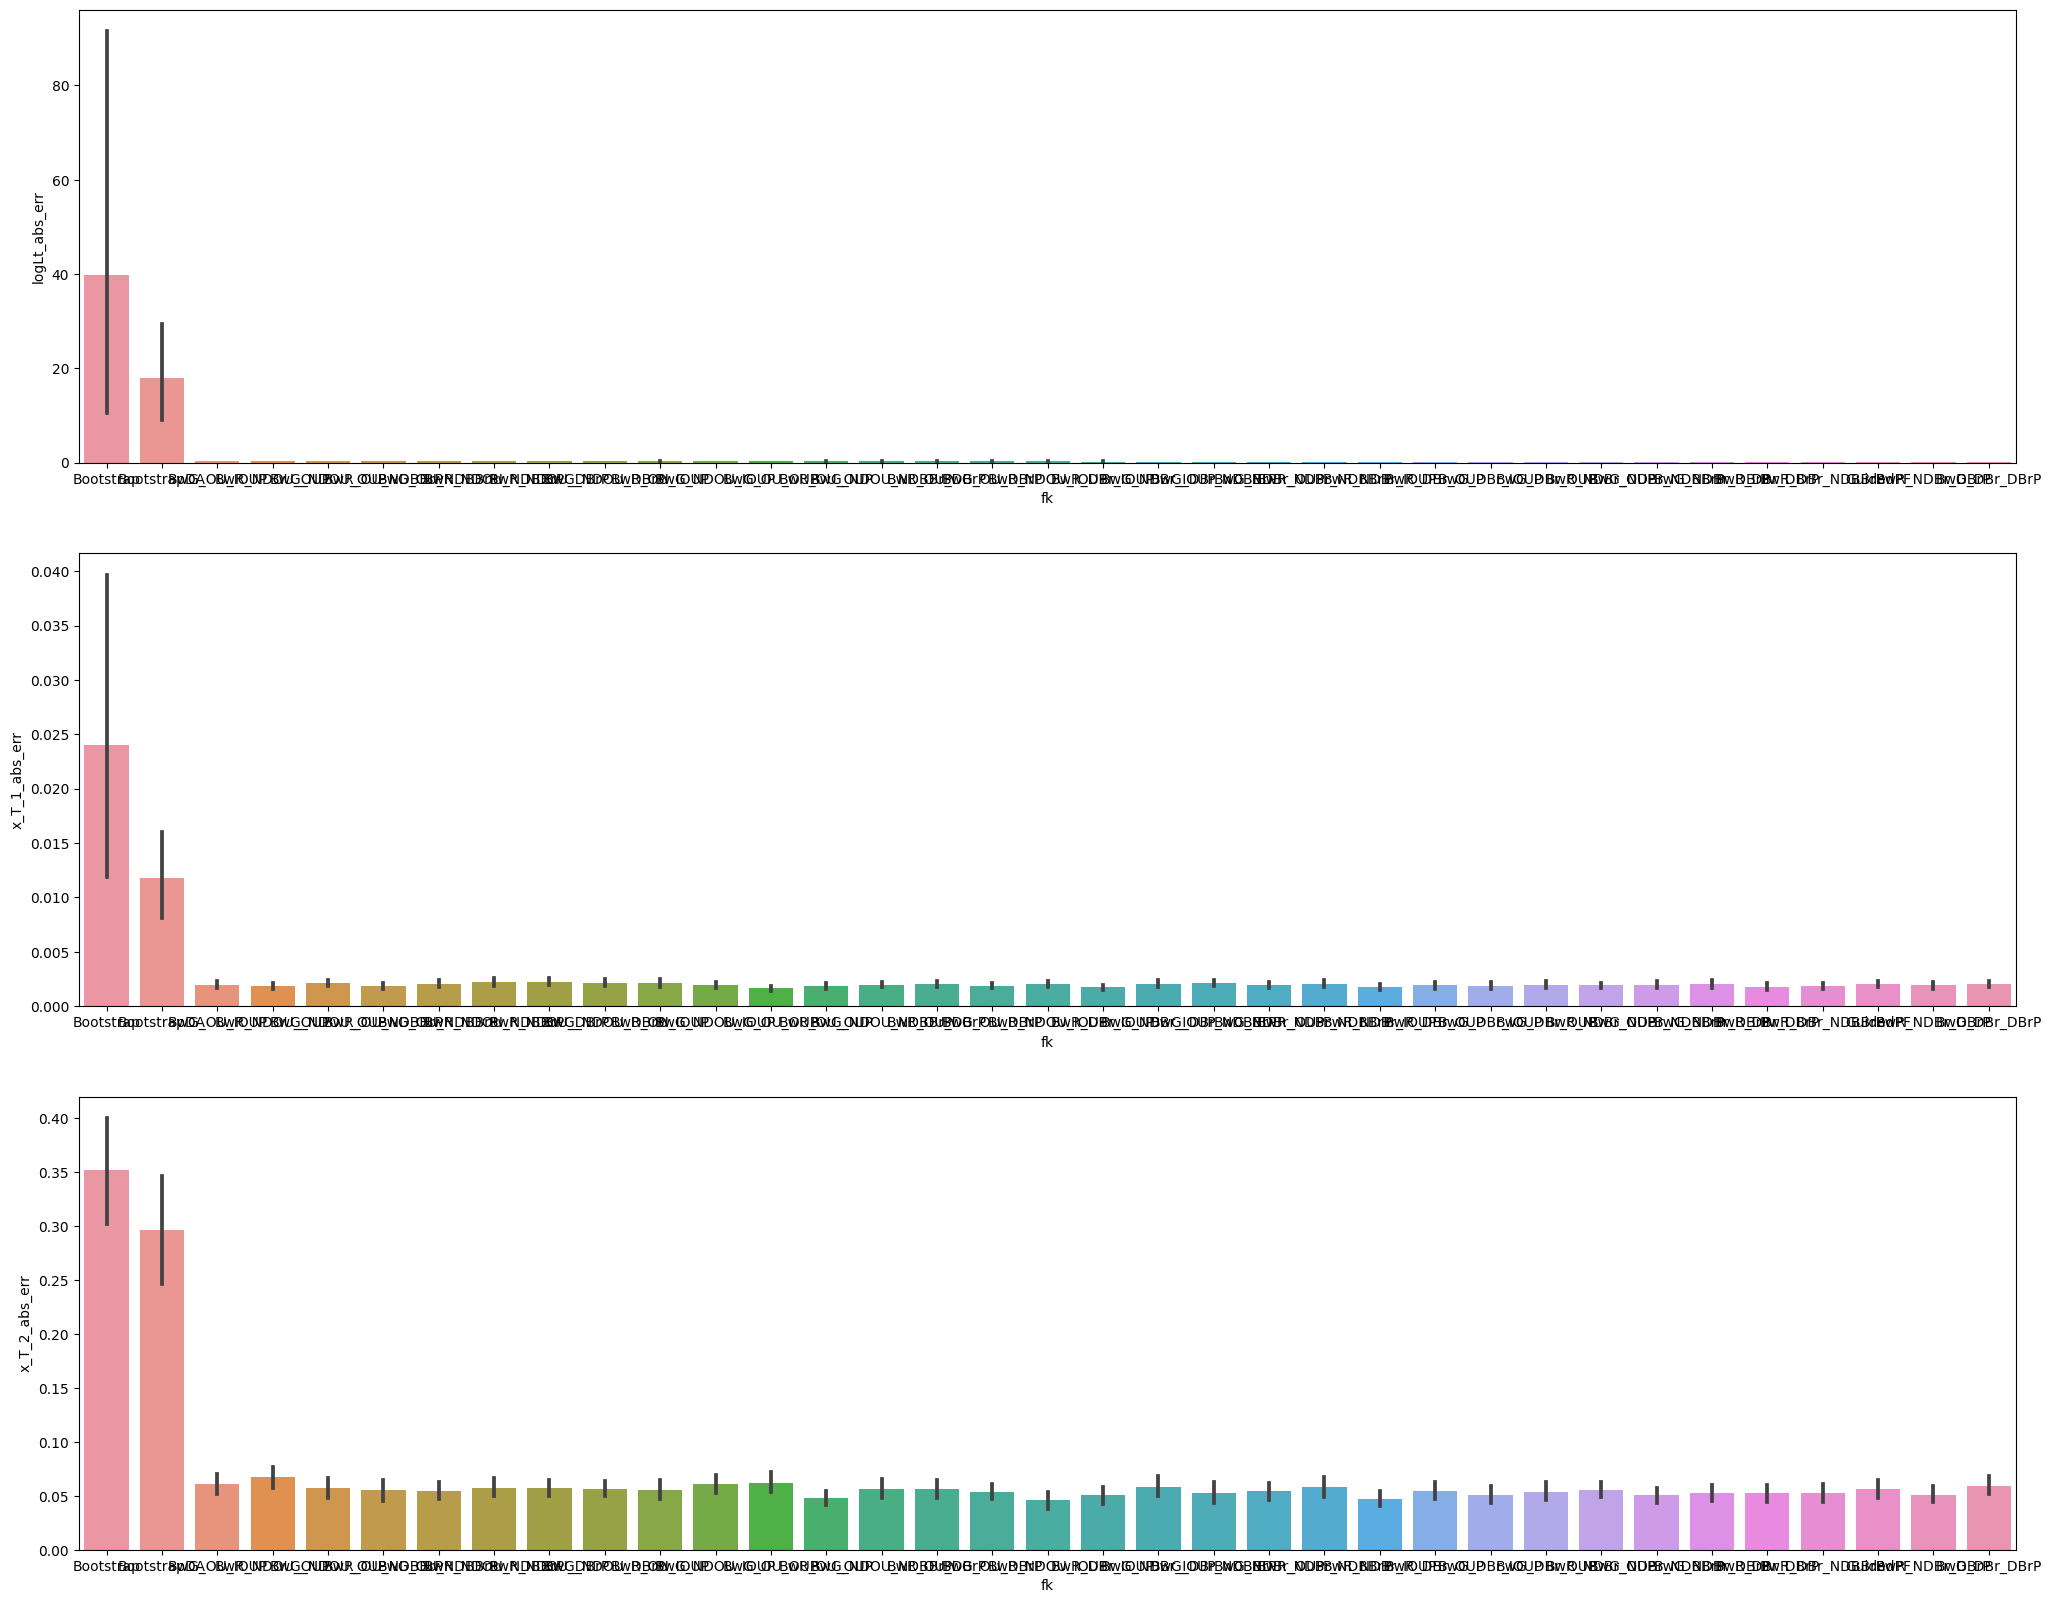

In [9]:
fig, axes = plt.subplots(dimX + 1, 1, figsize=(25, 20))
all_colnames = mae_df.columns.tolist()
colnames = [c for c in all_colnames if ('std' not in c.split('_')) and ('var' not in c.split('_'))]
axes = axes.ravel()

for i, ax in enumerate(axes):
    colname = abs_err_df.columns[i+1]
    sns.barplot(data=abs_err_df, order = mae_order, x='fk', y=colname, ax=ax)

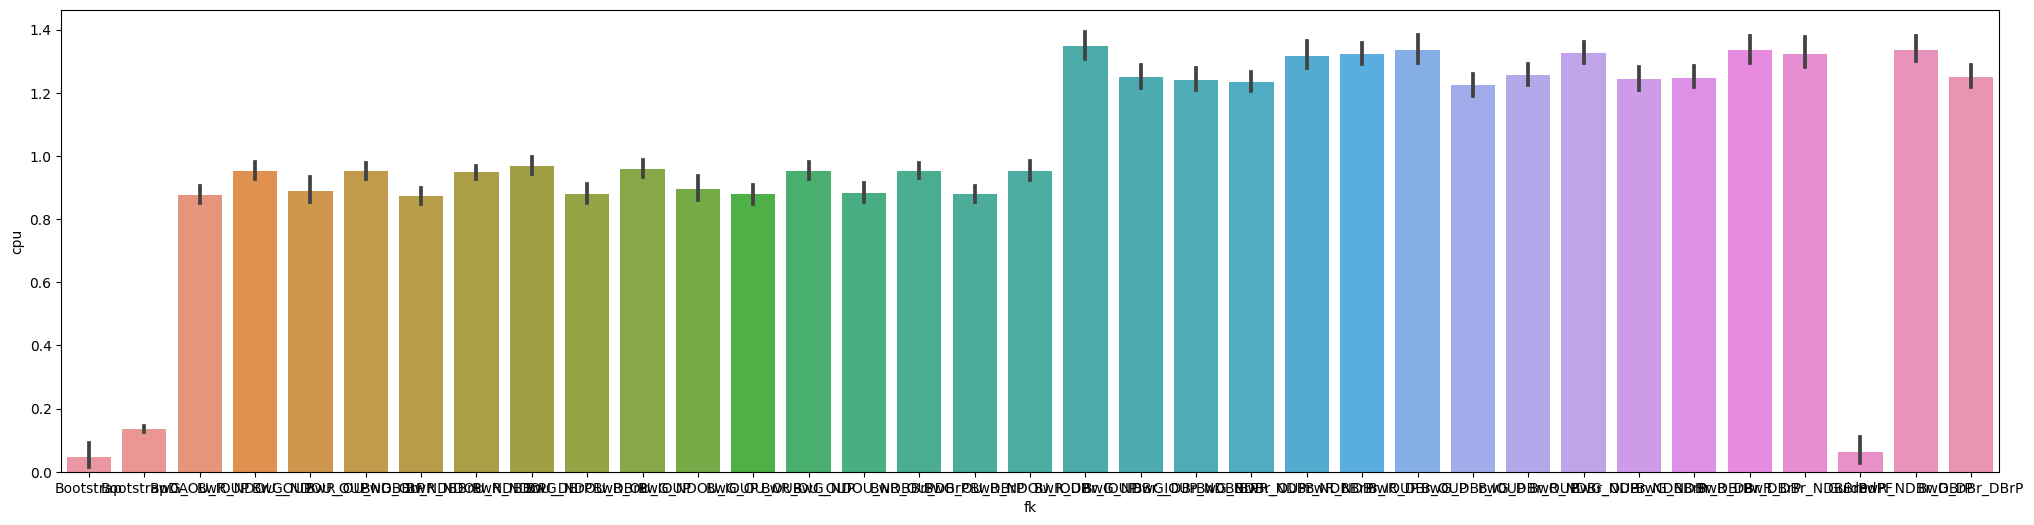

In [10]:
sns.barplot(x='fk', y='cpu', order = mae_order, data=cpu_df)
fig = plt.gcf()
fig.set_size_inches(25, 6)

In [11]:
mae_df.sort_values(by='logLt_abs_err', ascending=True)

,logLt_abs_err,x_T_1_abs_err,x_T_2_abs_err,x_T_var_1_abs_err,x_T_var_2_abs_err,x_T_std_1_abs_err,x_T_std_2_abs_err
fk,,,,,,,
BwG_DBr_DBrP,0.178944,0.002018,0.059316,0.000057,0.040013,0.001424,0.037420
BwR_NDBr_DBrP,0.179022,0.001932,0.051022,0.000063,0.040688,0.001609,0.038296
GuidedPF,0.181222,0.002007,0.056604,0.000051,0.044773,0.001283,0.041070
BwR_DBr_NDBBrP,0.182413,0.001869,0.052943,0.000050,0.036556,0.001278,0.034265
BwR_DBr_DBrP,0.186615,0.001808,0.052808,0.000056,0.034560,0.001423,0.032345
BwG_NDBr_DBrP,0.190390,0.002044,0.052364,0.000052,0.036292,0.001299,0.033686
BwG_NDBr_NDBBrP,0.190572,0.001992,0.050326,0.000049,0.036605,0.001225,0.033874
BwR_NDBr_OUP,0.192426,0.001909,0.055268,0.000054,0.037847,0.001347,0.035771
BwG_DBr_OUP,0.195483,0.001990,0.053119,0.000062,0.041144,0.001553,0.038393
